Image loaded successfully with shape: (1437, 1536)

Laplacian kernel:
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


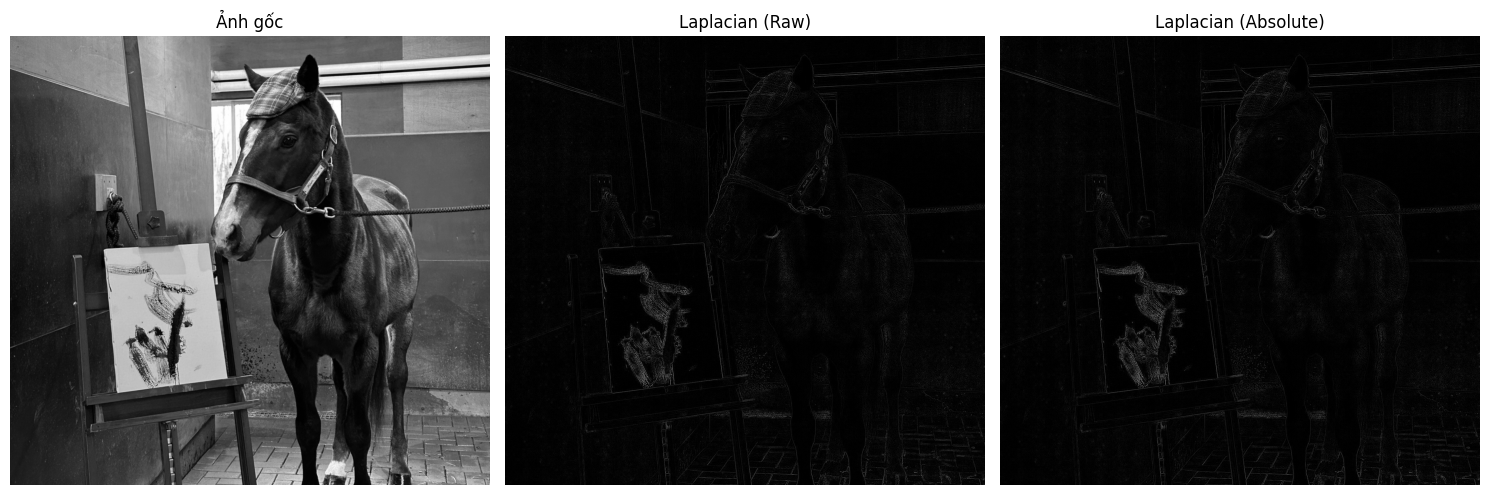

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load the image
img = cv2.imread('wonderacute.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    print(f"Image loaded successfully with shape: {img.shape}")
    
    h_laplacian = np.array([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=np.float32)
    
    print("\nLaplacian kernel:")
    print(h_laplacian)
    
    img_laplacian = cv2.filter2D(img, -1, h_laplacian)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Ảnh gốc')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_laplacian, cmap='gray')
    plt.title('Laplacian (Raw)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(img_laplacian), cmap='gray')
    plt.title('Laplacian (Absolute)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ảnh!")

In [2]:
# Define the edge enhancement kernel
# h_enhanced = delta - Laplacian
delta = np.array([[0, 0, 0],
                  [0, 1, 0],
                  [0, 0, 0]], dtype=np.float32)

h_enhanced = delta - h_laplacian

print("Edge enhancement kernel:")
print(h_enhanced)
print("\nThis is equivalent to:")
print(np.array([[0, -1, 0],
                [-1, 5, -1],
                [0, -1, 0]], dtype=np.float32))

Edge enhancement kernel:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]

This is equivalent to:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


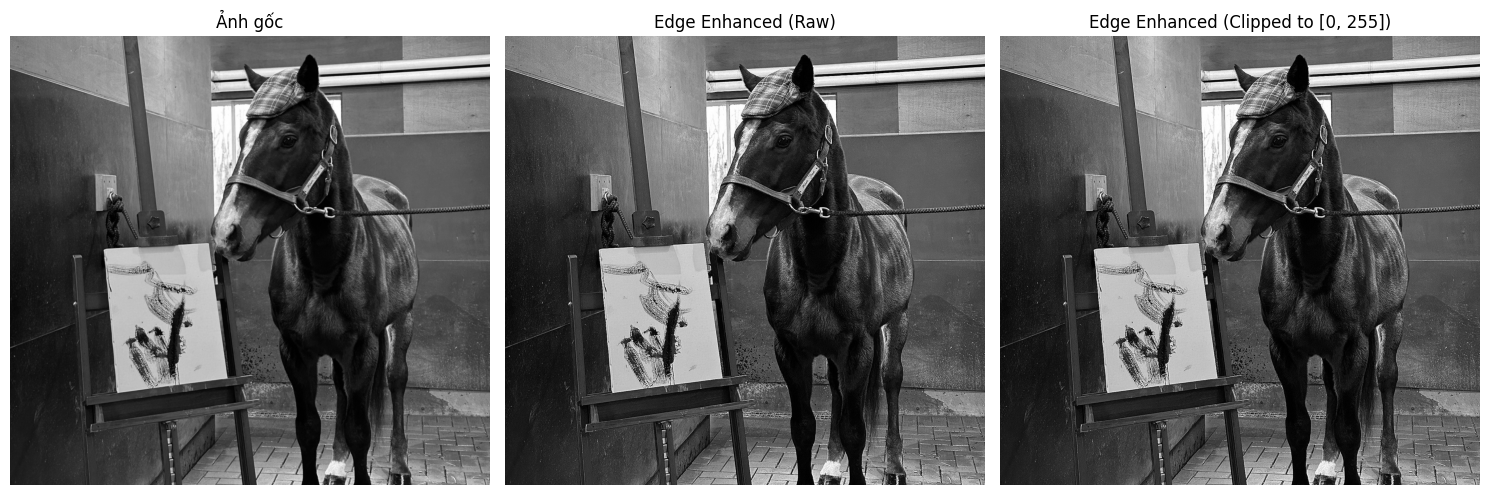

In [3]:
if img is not None:
    img_enhanced = cv2.filter2D(img, -1, h_enhanced)
    
    img_enhanced_clipped = np.clip(img_enhanced, 0, 255).astype(np.uint8)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Ảnh gốc')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_enhanced, cmap='gray')
    plt.title('Edge Enhanced (Raw)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_enhanced_clipped, cmap='gray')
    plt.title('Edge Enhanced (Clipped to [0, 255])')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ảnh!")

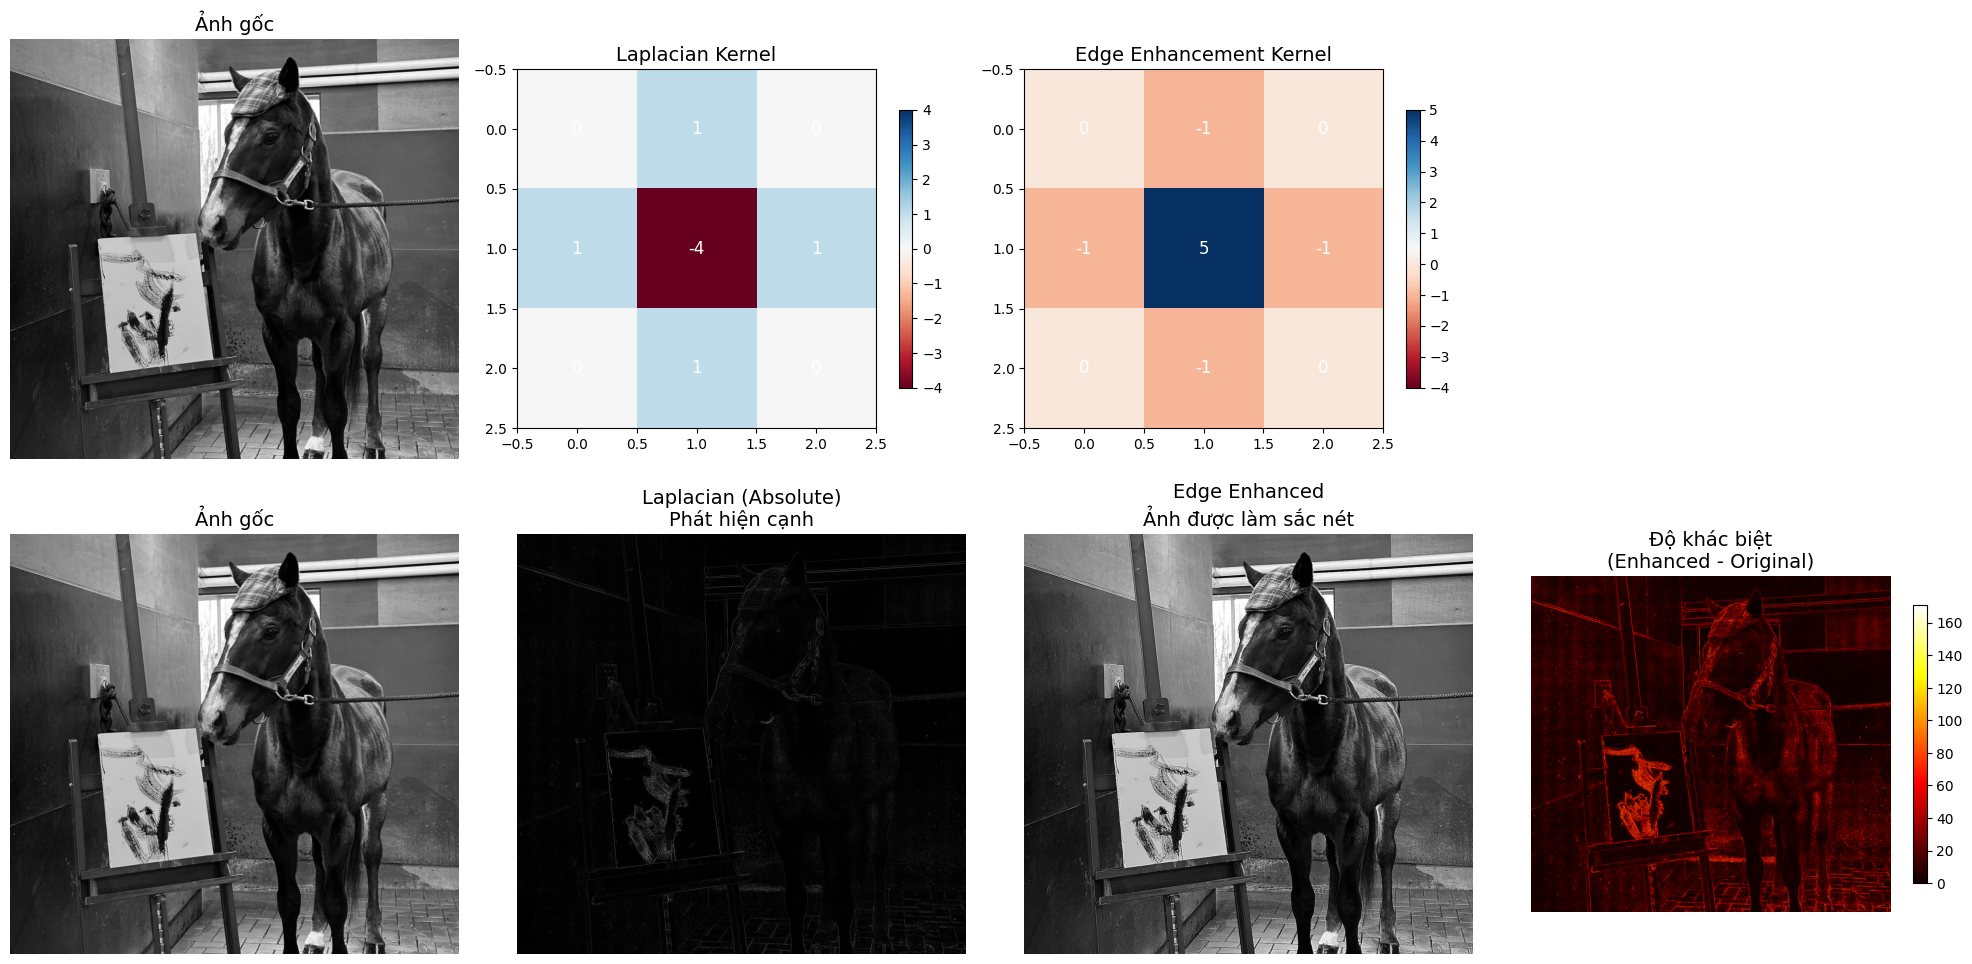

In [ ]:
if img is not None:
    plt.figure(figsize=(20, 10))
    
    # Row 1: Original and kernels
    plt.subplot(2, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Ảnh gốc', fontsize=14)
    plt.axis('off')
    
    plt.subplot(2, 4, 2)
    plt.imshow(h_laplacian, cmap='RdBu', vmin=-4, vmax=4)
    plt.title('Laplacian Kernel', fontsize=14)
    plt.colorbar(shrink=0.6)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, f'{h_laplacian[i, j]:.0f}', 
                    ha='center', va='center', fontsize=12, color='white')
    
    plt.subplot(2, 4, 3)
    plt.imshow(h_enhanced, cmap='RdBu', vmin=-4, vmax=5)
    plt.title('Edge Enhancement Kernel', fontsize=14)
    plt.colorbar(shrink=0.6)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, f'{h_enhanced[i, j]:.0f}', 
                    ha='center', va='center', fontsize=12, color='white')
    
    # Row 2: Results
    plt.subplot(2, 4, 5)
    plt.imshow(img, cmap='gray')
    plt.title('Ảnh gốc', fontsize=14)
    plt.axis('off')
    
    plt.subplot(2, 4, 6)
    plt.imshow(np.abs(img_laplacian), cmap='gray')
    plt.title('Laplacian (Absolute)\nPhát hiện cạnh', fontsize=14)
    plt.axis('off')
    
    plt.subplot(2, 4, 7)
    plt.imshow(img_enhanced_clipped, cmap='gray')
    plt.title('Edge Enhanced\nẢnh được làm sắc nét', fontsize=14)
    plt.axis('off')
    
    plt.subplot(2, 4, 8)
    diff = img_enhanced_clipped.astype(float) - img.astype(float)
    plt.imshow(np.abs(diff), cmap='hot')
    plt.title('Độ khác biệt\n(Enhanced - Original)', fontsize=14)
    plt.axis('off')
    plt.colorbar(shrink=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ảnh!")